## Montar Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
path = '/content/drive/MyDrive/Meli_Case'

In [ ]:
import sys
sys.path.append(path)

## Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp
import shap
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score, classification_report

## Funções

In [ ]:
from functions import plot_roc_curves, encontrar_threshold_max_lucro, calculate_profit, metricas_fraude, analisar_metricas_por_decil

## Base

In [ ]:
base = pd.read_excel(f"{path}/fraud_dataset.xlsx")
base = base.rename(columns={col: f"var_{col}" for col in base.columns if len(col) == 1 and col.isalpha()})

In [ ]:
variaveis = ["var_Q", "var_R", "var_S", 'Monto']

for col in variaveis:
    base[col] = base[col].apply(lambda x: np.nan if isinstance(x, datetime) else x)

    base[col] = base[col].astype(str).str.replace(",", "").str.replace(" ", "").replace("None", np.nan)
    base[col] = pd.to_numeric(base[col], errors='coerce')

In [ ]:
for col in ["var_C", "var_F", "var_G"]:
    base[f"{col}_log"] = np.log1p(base[col])

In [ ]:
def mapear_pais(pais):
    if pais in ['BR', 'AR', 'MX']:
        return pais
    elif pais in ['ES', 'US', 'UY']:
        return 'ES_US_UY'
    else:
        return 'OUTROS'

base['pais_agg'] = base['var_J'].apply(mapear_pais)

In [ ]:
pais_agg_dummies = pd.get_dummies(base['pais_agg'], prefix='pais_agg')
pais_agg_dummies = pais_agg_dummies.astype(int)

In [ ]:
base = pd.concat([base, pais_agg_dummies], axis=1)
base

In [ ]:
base['var_K_100'] = (base['var_K'] * 100).round()

In [14]:
drop_col = ['var_C', 'var_F', 'var_G', 'var_J', 'pais_agg', 'var_K']
base = base.drop(columns=drop_col, errors='ignore')
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   var_A              16880 non-null  int64  
 1   var_B              16880 non-null  int64  
 2   var_D              16880 non-null  int64  
 3   var_E              16880 non-null  int64  
 4   var_H              16880 non-null  int64  
 5   var_I              16880 non-null  int64  
 6   var_L              16880 non-null  int64  
 7   var_M              16880 non-null  int64  
 8   var_N              16880 non-null  int64  
 9   var_O              16880 non-null  int64  
 10  var_P              16880 non-null  int64  
 11  var_Q              16863 non-null  float64
 12  var_R              16877 non-null  float64
 13  var_S              15575 non-null  float64
 14  Monto              16413 non-null  float64
 15  Fraude             16880 non-null  int64  
 16  var_C_log          136

In [15]:
df = base[base['Monto'].notna()]

## Treino, Teste e Validação

In [ ]:
rf_fs = ['var_S',
 'Monto',
 'var_C_log',
 'var_B',
 'pais_agg_ES_US_UY',
 'var_K_100',
 'var_P',
 'var_M',
 'var_L',
 'var_A',
 'var_E',
 'pais_agg_MX',
 'var_F_log',
 'pais_agg_AR',
 'pais_agg_BR',
 'var_Q',
 'var_D']

In [17]:
X = df[rf_fs]
y = df["Fraude"]

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=13)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=13)

In [19]:
X_train.shape, X_test.shape, X_val.shape

((9847, 17), (3283, 17), (3283, 17))

## Optimização de Hiperparâmetros

In [20]:
space = {
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
    'gamma': hp.uniform('gamma', 0, 5),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 5.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 5.0)
}

In [21]:
def objective(params):
    params['max_depth'] = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=13,
        n_jobs=-1,
        **params
    )
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    return {'loss': -auc, 'status': STATUS_OK}

In [22]:
trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trials,
            rstate=np.random.default_rng(13))

print("Melhores hiperparâmetros:", best)

100%|██████████| 50/50 [00:28<00:00,  1.72trial/s, best loss: -0.8210859327644893]
Melhores hiperparâmetros: {'colsample_bytree': np.float64(0.6406986982852445), 'gamma': np.float64(0.7006462287403816), 'learning_rate': np.float64(0.06789620347195029), 'max_depth': np.float64(10.0), 'min_child_weight': np.float64(7.0), 'n_estimators': np.float64(230.0), 'reg_alpha': np.float64(1.0503366753204815), 'reg_lambda': np.float64(3.379213209035674), 'subsample': np.float64(0.8219521946421204)}


In [57]:
best

{'colsample_bytree': np.float64(0.6406986982852445),
 'gamma': np.float64(0.7006462287403816),
 'learning_rate': np.float64(0.06789620347195029),
 'max_depth': np.float64(10.0),
 'min_child_weight': np.float64(7.0),
 'n_estimators': np.float64(230.0),
 'reg_alpha': np.float64(1.0503366753204815),
 'reg_lambda': np.float64(3.379213209035674),
 'subsample': np.float64(0.8219521946421204)}

## Modelagem

In [24]:
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=13,
    n_jobs=-1,
    max_depth=int(best['max_depth']),
    learning_rate=best['learning_rate'],
    n_estimators=int(best['n_estimators']),
    gamma=best['gamma'],
    min_child_weight=int(best['min_child_weight']),
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda']
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6406986982852445), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=np.float64(0.7006462287403816), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.06789620347195029), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=230, n_jobs=-1,
              num_parallel_tree=None, random_state=13, ...)

In [25]:
y_probs_test = final_model.predict_proba(X_test)[:, 1]
y_probs_val = final_model.predict_proba(X_val)[:, 1]

## Avaliação do Modelo

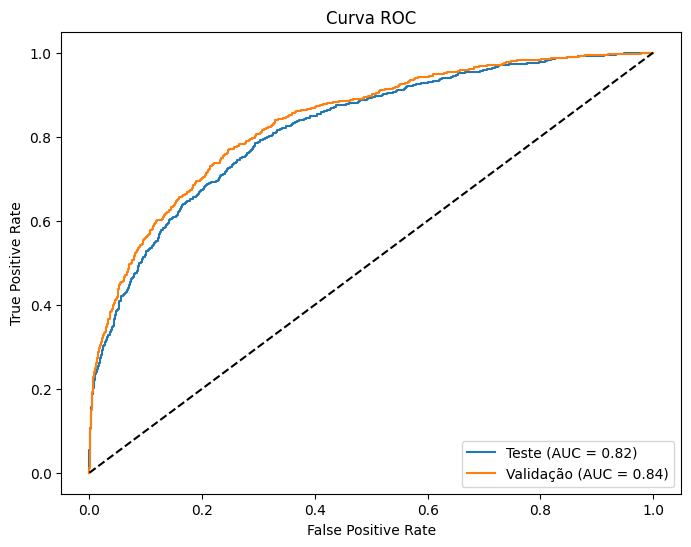

In [26]:
plot_roc_curves(y_test, y_probs_test, y_val, y_probs_val)

In [ ]:
ks_test = ks_2samp(y_probs_test[y_test == 0], y_probs_test[y_test == 1]).statistic
ks_val = ks_2samp(y_probs_val[y_val == 0], y_probs_val[y_val == 1]).statistic

print(f"KS Test: {ks_test:.4f}")
print(f"KS Val: {ks_val:.4f}")

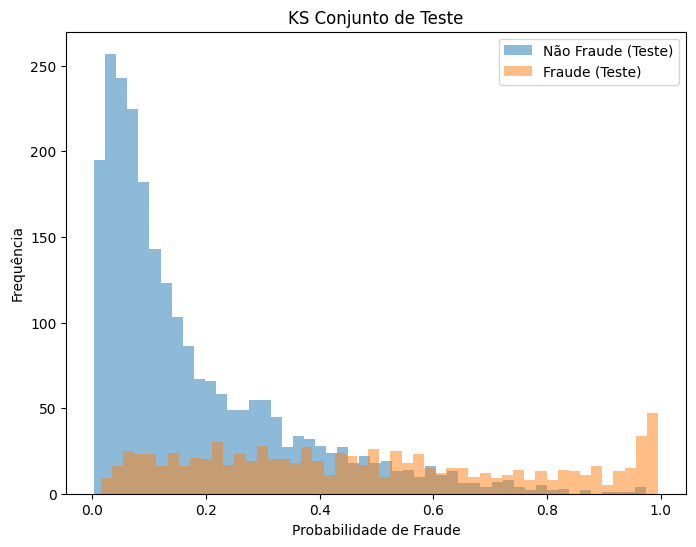

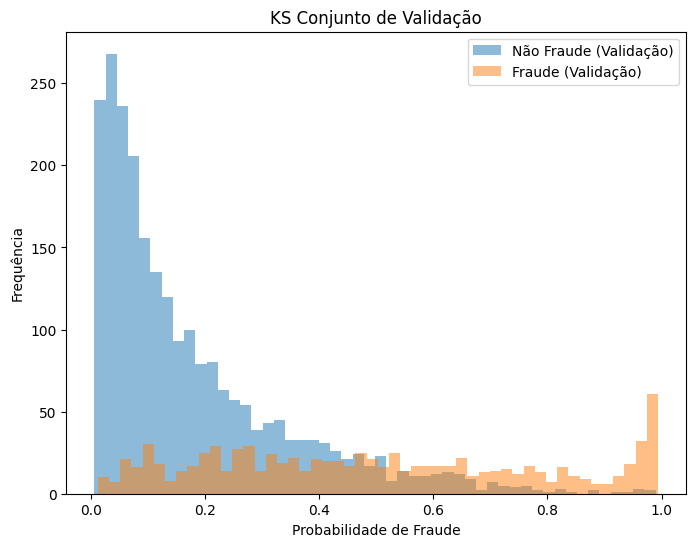

In [28]:
plt.figure(figsize=(8, 6))
plt.hist(y_probs_test[y_test == 0], bins=50, alpha=0.5, label='Não Fraude (Teste)')
plt.hist(y_probs_test[y_test == 1], bins=50, alpha=0.5, label='Fraude (Teste)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Teste')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(y_probs_val[y_val == 0], bins=50, alpha=0.5, label='Não Fraude (Validação)')
plt.hist(y_probs_val[y_val == 1], bins=50, alpha=0.5, label='Fraude (Validação)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Validação')
plt.legend()
plt.show()


In [29]:
ks_values = [ks_test, ks_val]
groups = ['Teste', 'Validação']

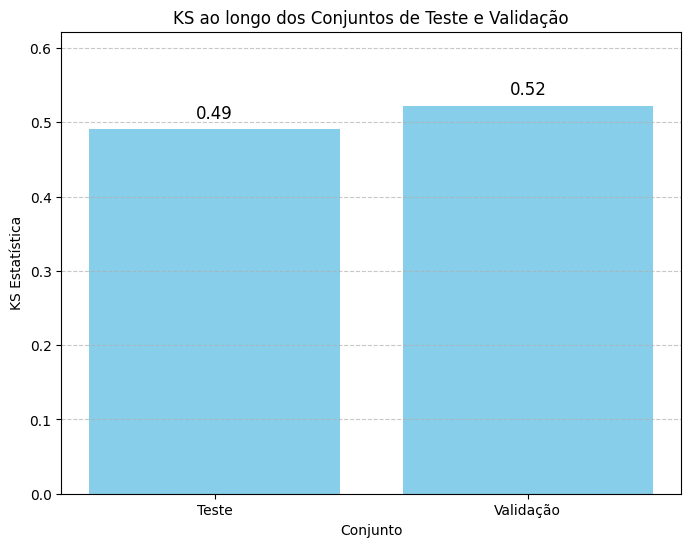

In [30]:
plt.figure(figsize=(8, 6))
bars = plt.bar(groups, ks_values, color='skyblue')
plt.xlabel("Conjunto")
plt.ylabel("KS Estatística")
plt.title("KS ao longo dos Conjuntos de Teste e Validação")
for bar, ks_val in zip(bars, ks_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{ks_val:.2f}",
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(ks_values) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
booster = final_model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df.sort_values(by='Importance', ascending=False, inplace=True)
importance_df

,Feature,Importance
4,pais_agg_ES_US_UY,63.643700
11,pais_agg_MX,21.031193
3,var_B,7.714569
15,var_Q,3.881535
9,var_A,3.619111
6,var_P,3.577941
5,var_K_100,3.526314
0,var_S,3.172481
16,var_D,3.061165
2,var_C_log,2.878584


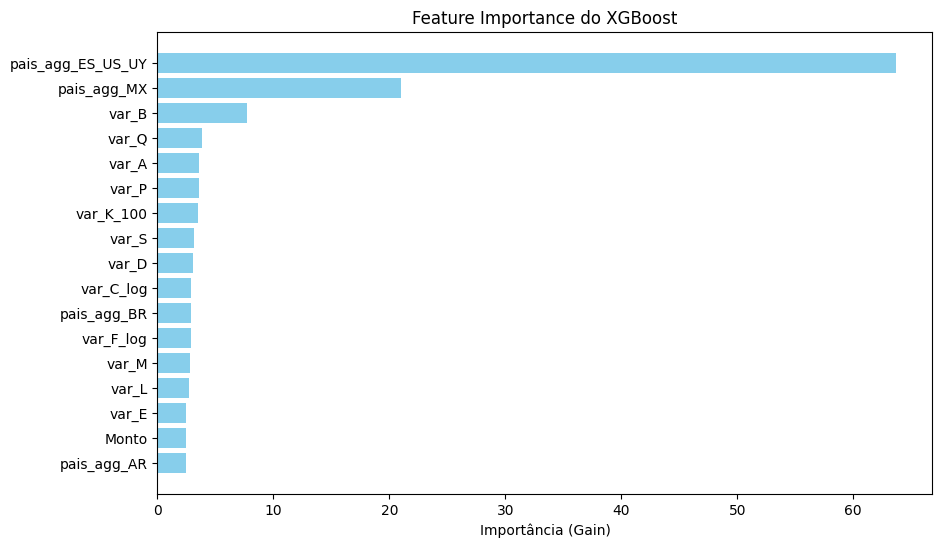

In [32]:
importance_df.sort_values(by='Importance', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importância (Gain)")
plt.title("Feature Importance do XGBoost")
plt.show()

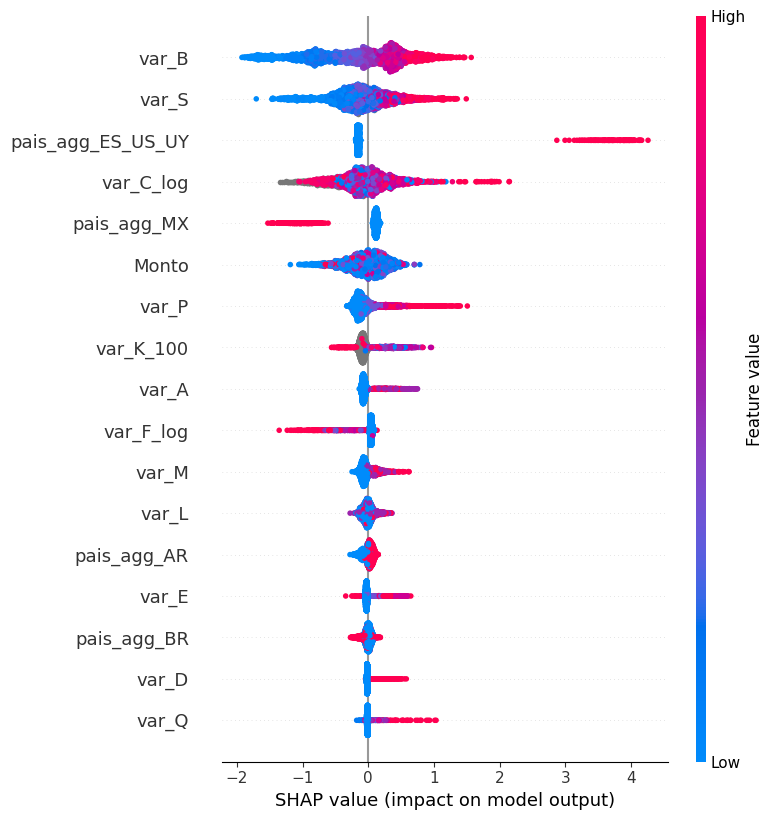

In [33]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)

## Escolha do Threshold a partir do F1-Score

In [ ]:
thresholds = np.linspace(0.01, 0.99, 100)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (y_probs_test > t).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

best_threshold_f1 = thresholds[np.argmax(f1_scores)].round(2)
print("Melhor threshold para F1-score:", best_threshold_f1)
print("F1-score correspondente:", np.max(f1_scores).round(4))

In [ ]:
for i in range(len(thresholds)):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precisions[i]:.4f}, Recall: {recalls[i]:.4f}, F1-Score: {f1_scores[i]:.4f}")

In [ ]:
# best_threshold_f1 = 0.4
best_threshold_f1

In [ ]:
y_pred_test = (y_probs_test > best_threshold_f1).astype(int)
y_pred_val = (y_probs_val > best_threshold_f1).astype(int)

In [38]:
auc_test = roc_auc_score(y_test, y_probs_test)
f1_test = f1_score(y_test, y_pred_test)
auc_val = roc_auc_score(y_val, y_probs_val)
f1_val = f1_score(y_val, y_pred_val)

In [ ]:
print("AUC (Teste):", auc_test)
print("F1-score (Teste):", f1_test)
print("AUC (validação):", auc_val)
print("F1-score (validação):", f1_val)

In [40]:
metrics = {
    'Métrica': ['AUC', 'F1-Score'],
    'Teste': [auc_test, f1_test],
    'Validação': [auc_val, f1_val]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Métrica,Teste,Validação
0,AUC,0.821086,0.837524
1,F1-Score,0.612903,0.628571


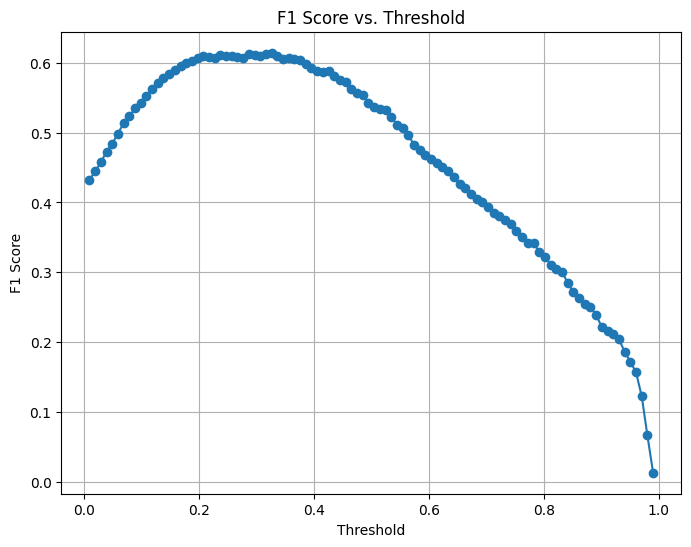

In [41]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold")
plt.grid(True)
plt.show()

## Avaliação do Modelo

In [42]:
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

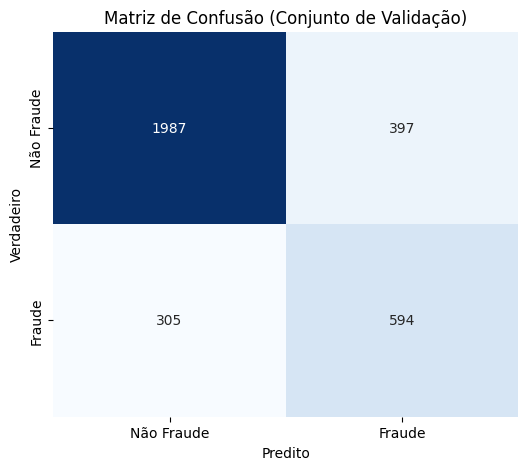

In [43]:
labels = ["Não Fraude", "Fraude"]
cm_matrix = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.title('Matriz de Confusão (Conjunto de Validação)')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

In [44]:
report = classification_report(y_val, y_pred_val, target_names=["Não Fraude", "Fraude"])
print("Classification Report (Validação):\n")
print(report)

Classification Report (Validação):

              precision    recall  f1-score   support

  Não Fraude       0.87      0.83      0.85      2384
      Fraude       0.60      0.66      0.63       899

    accuracy                           0.79      3283
   macro avg       0.73      0.75      0.74      3283
weighted avg       0.79      0.79      0.79      3283



## Escolha do Threshold a partir do Lucro Máximo

In [45]:
best_threshold_f1

np.float64(0.33)

Melhor Threshold para Lucro: 0.19
Lucro Máximo: 51644.56


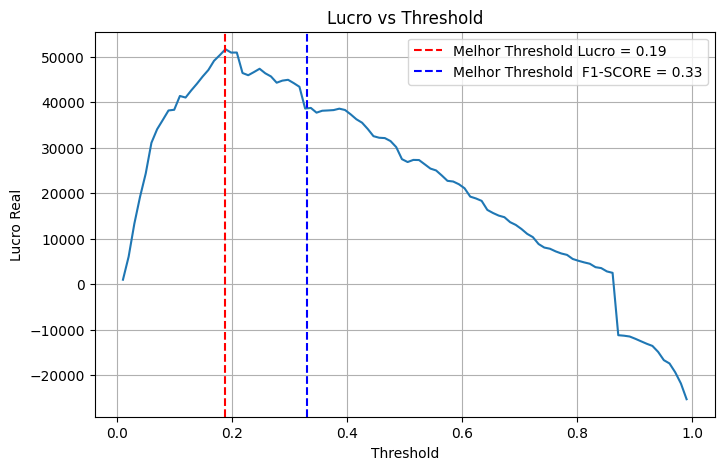

In [46]:
montos_val = X_val['Monto'].values

melhor_threshold, lucro_max = encontrar_threshold_max_lucro(y_val, y_probs_val, montos_val, best_threshold_f1)

In [47]:
calculate_profit(y_val, y_pred_val, X_val['Monto'])

Lucro: 92432.61
Prejuizo: -53648.81
Save : 80019.04
Saldo Negativo: -15457.38
Balanço Total: 103345.46
Lucro Real: 38783.80


## Métricas de Fraude

In [48]:
metricas_fraude(cm, y_test, y_pred_test)

Métricas específicas de Fraude:
Detection Rate (Recall):     0.6333
Alert Rate (False Alarm):    0.4062
Hit Rate (Precision):        0.5938
Rejection Rate (Alertas):    0.2924


In [49]:
metricas_fraude(cm, y_val, y_pred_val)

Métricas específicas de Fraude:
Detection Rate (Recall):     0.6607
Alert Rate (False Alarm):    0.4006
Hit Rate (Precision):        0.5994
Rejection Rate (Alertas):    0.3019


## Avaliar por Decil

In [50]:
analisar_metricas_por_decil(y_test, y_probs_test)

,Decil,Score Mínimo,Score Máximo,Transações,Fraudes,Hit Rate,Detection Rate,Alert Rate
0,10,639,995,329,270,0.8207,0.3000,0.1002
1,9,451,638,328,178,0.5427,0.1978,0.0999
2,8,322,450,328,129,0.3933,0.1433,0.0999
3,7,235,322,328,98,0.2988,0.1089,0.0999
4,6,166,234,328,80,0.2439,0.0889,0.0999
5,5,115,166,329,44,0.1337,0.0489,0.1002
6,4,82,115,328,41,0.1250,0.0456,0.0999
7,3,56,82,328,33,0.1006,0.0367,0.0999
8,2,33,56,328,18,0.0549,0.0200,0.0999
9,1,4,33,329,9,0.0274,0.0100,0.1002


In [51]:
analisar_metricas_por_decil(y_val, y_probs_val)

,Decil,Score Mínimo,Score Máximo,Transações,Fraudes,Hit Rate,Detection Rate,Alert Rate
0,10,653,994,329,279,0.8480,0.3103,0.1002
1,9,462,653,328,186,0.5671,0.2069,0.0999
2,8,332,462,328,128,0.3902,0.1424,0.0999
3,7,238,332,328,104,0.3171,0.1157,0.0999
4,6,173,237,328,75,0.2287,0.0834,0.0999
5,5,122,173,329,32,0.0973,0.0356,0.1002
6,4,83,122,328,46,0.1402,0.0512,0.0999
7,3,56,83,328,25,0.0762,0.0278,0.0999
8,2,30,56,328,15,0.0457,0.0167,0.0999
9,1,6,30,329,9,0.0274,0.0100,0.1002


## Avaliar o público sem a variável Monto

In [52]:
X_null = base[base['Monto'].isna()][rf_fs]
y_null = base[base['Monto'].isna()]["Fraude"]

In [53]:
y_probs_null = final_model.predict_proba(X_null)[:, 1]
y_pred_null = (y_probs_null > best_threshold_f1).astype(int)

In [54]:
f1_null = f1_score(y_null, y_pred_null)
auc_null = roc_auc_score(y_null, y_probs_null)

In [55]:
print("AUC (validação):", auc_val.round(2))
print("F1-score (validação):", round(f1_val, 2))
print("AUC (Monto):", auc_null.round(2))
print("F1-score (Monto):", round(f1_null, 2))

AUC (validação): 0.84
F1-score (validação): 0.63
AUC (Monto): 0.79
F1-score (Monto): 0.52


## Salvar

In [56]:
# ! jupyter nbconvert --to html 02_Modelagem_XGBoost.ipynb